# 02 — Mel Spectrogram Extraction (CNN Input)

Extracts **2D mel spectrograms** (128 mel bands × 173 time frames) from every audio clip
and saves them as numpy arrays for CNN training.

**Output shape:** `(N, 128, 173)` float32, normalized per-sample to [0, 1]

Long recordings are sliced into non-overlapping 4-second segments.
Near-silent segments (RMS < 0.001) are discarded.

In [8]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from src.feature_extraction import (
    extract_mel_spectrogram_2d,
    extract_mel_segments_from_long_file,
)
from src.utils import get_urbansound_metadata, get_audio_file_path

DATASET_PATH      = '../data/raw/UrbanSound8K'
CUSTOM_TRANS_PATH = '../data/raw/transpotation'
CUSTOM_CONV_PATH  = '../data/raw/custom_audio/conversation'
OUTPUT_DIR        = '../data/processed/spectrograms'
SAMPLE_RATE       = 22050
SEGMENT_DURATION  = 4.0

# UrbanSound8K class IDs to use
TRANSPORT_IDS    = {1, 5, 8}   # car_horn, engine_idling, siren
CONVERSATION_IDS = set()       # not using children_playing — not real speech

LABEL_TRANSPORT    = 0
LABEL_CONVERSATION = 1

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1. UrbanSound8K — transportation & conversation clips

In [9]:
meta = get_urbansound_metadata(DATASET_PATH)
mask = meta['classID'].isin(TRANSPORT_IDS | CONVERSATION_IDS)
df_filtered = meta[mask].reset_index(drop=True)
print(f'US8K clips to process: {len(df_filtered)}')
print(df_filtered['class'].value_counts().to_string())

X_us8k, y_us8k, meta_us8k = [], [], []

for _, row in tqdm(df_filtered.iterrows(), total=len(df_filtered), desc='US8K'):
    fp = get_audio_file_path(DATASET_PATH, int(row['fold']), row['slice_file_name'])
    if not os.path.isfile(fp):
        continue
    label = LABEL_TRANSPORT if int(row['classID']) in TRANSPORT_IDS else LABEL_CONVERSATION
    mel = extract_mel_spectrogram_2d(fp, sample_rate=SAMPLE_RATE, duration=SEGMENT_DURATION)
    if mel is None:
        continue
    X_us8k.append(mel)
    y_us8k.append(label)
    meta_us8k.append({'source': 'urbansound8k', 'class': row['class'], 'file': fp})

print(f'Extracted: {len(X_us8k)} US8K mel spectrograms')
print(f'  Transportation: {sum(1 for l in y_us8k if l == 0)}')
print(f'  Conversation:   {sum(1 for l in y_us8k if l == 1)}')

US8K clips to process: 3358
class
children_playing    1000
engine_idling       1000
siren                929
car_horn             429


US8K:   0%|          | 0/3358 [00:00<?, ?it/s]

Extracted: 3326 US8K mel spectrograms
  Transportation: 2334
  Conversation:   992


## 2. Custom transportation recordings

In [10]:
X_trans, y_trans, meta_trans = [], [], []

trans_files = sorted([
    f for f in os.listdir(CUSTOM_TRANS_PATH)
    if f.lower().endswith(('.mp3', '.wav', '.flac', '.ogg'))
])
print(f'Found {len(trans_files)} custom transportation files')

for fname in tqdm(trans_files, desc='Custom Transportation'):
    fp = os.path.join(CUSTOM_TRANS_PATH, fname)
    mel_list, n_total = extract_mel_segments_from_long_file(
        fp, sample_rate=SAMPLE_RATE, segment_duration=SEGMENT_DURATION
    )
    print(f'  {fname}: {len(mel_list)}/{n_total} segments kept')
    for mel in mel_list:
        X_trans.append(mel)
        y_trans.append(LABEL_TRANSPORT)
        meta_trans.append({'source': 'custom_transport', 'class': 'transportation', 'file': fp})

print(f'\nTotal custom transportation segments: {len(X_trans)}')

Found 26 custom transportation files


Custom Transportation:   0%|          | 0/26 [00:00<?, ?it/s]

  arunangshubanerjee-suburban-alley-traffic-ambience-359577.mp3: 5/5 segments kept
  arunangshubanerjee-traffic-commotion-with-siren-and-car-horns-urban-street-noise-457233.mp3: 7/7 segments kept
  dkfilms-highway-traffic-ambience-indian-sfx-library-266395.mp3: 15/15 segments kept
  freesound_community-city-traffic-noise2-16695.mp3: 156/156 segments kept
  freesound_community-continuous-traffic-19746.mp3: 200/200 segments kept
  freesound_community-driving-by-noisy-car-33855.mp3: 6/6 segments kept
  freesound_community-galle-road-51183.mp3: 66/66 segments kept
  freesound_community-road-noise-1-72297.mp3: 13/13 segments kept
  freesound_community-road-noise-2-59478.mp3: 34/34 segments kept
  freesound_community-street-ambience-of-sri-lanka-29093.mp3: 13/13 segments kept
  freesound_community-traffic-19979.mp3: 26/26 segments kept
  freesound_community-traffic-construction1-35557.mp3: 8/8 segments kept
  freesound_community-train-departure-72609.mp3: 15/15 segments kept
  freesound_comm

## 3. Custom conversation recordings

In [ ]:
X_conv, y_conv, meta_conv = [], [], []

conv_files = sorted([
    f for f in os.listdir(CUSTOM_CONV_PATH)
    if f.lower().endswith(('.mp3', '.wav', '.flac', '.ogg', '.m4a'))
])
print(f'Found {len(conv_files)} custom conversation files')

for fname in tqdm(conv_files, desc='Custom Conversation'):
    fp = os.path.join(CUSTOM_CONV_PATH, fname)
    mel_list, n_total = extract_mel_segments_from_long_file(
        fp, sample_rate=SAMPLE_RATE, segment_duration=SEGMENT_DURATION
    )
    print(f'  {fname}: {len(mel_list)}/{n_total} segments kept')
    for mel in mel_list:
        X_conv.append(mel)
        y_conv.append(LABEL_CONVERSATION)
        meta_conv.append({'source': 'custom_conversation', 'class': 'conversation', 'file': fp})

print(f'\nTotal custom conversation segments: {len(X_conv)}')

## 4. Combine & save

In [12]:
X_all = np.array(X_us8k + X_trans + X_conv, dtype=np.float32)
y_all = np.array(y_us8k + y_trans + y_conv, dtype=np.int32)
meta_all = pd.DataFrame(meta_us8k + meta_trans + meta_conv)

print(f'Combined dataset shape: X={X_all.shape}, y={y_all.shape}')
print(f'Transportation (0): {(y_all == 0).sum()}')
print(f'Conversation   (1): {(y_all == 1).sum()}')
print(f'Memory usage: {X_all.nbytes / 1e6:.1f} MB')

np.save(os.path.join(OUTPUT_DIR, 'X.npy'), X_all)
np.save(os.path.join(OUTPUT_DIR, 'y.npy'), y_all)
meta_all.to_csv(os.path.join(OUTPUT_DIR, 'metadata.csv'), index=False)
print(f'\nSaved to {OUTPUT_DIR}/')

Combined dataset shape: X=(5096, 128, 173), y=(5096,)
Transportation (0): 3287
Conversation   (1): 1809
Memory usage: 451.4 MB

Saved to ../data/processed/spectrograms/


## 5. Verify — sample spectrogram grid

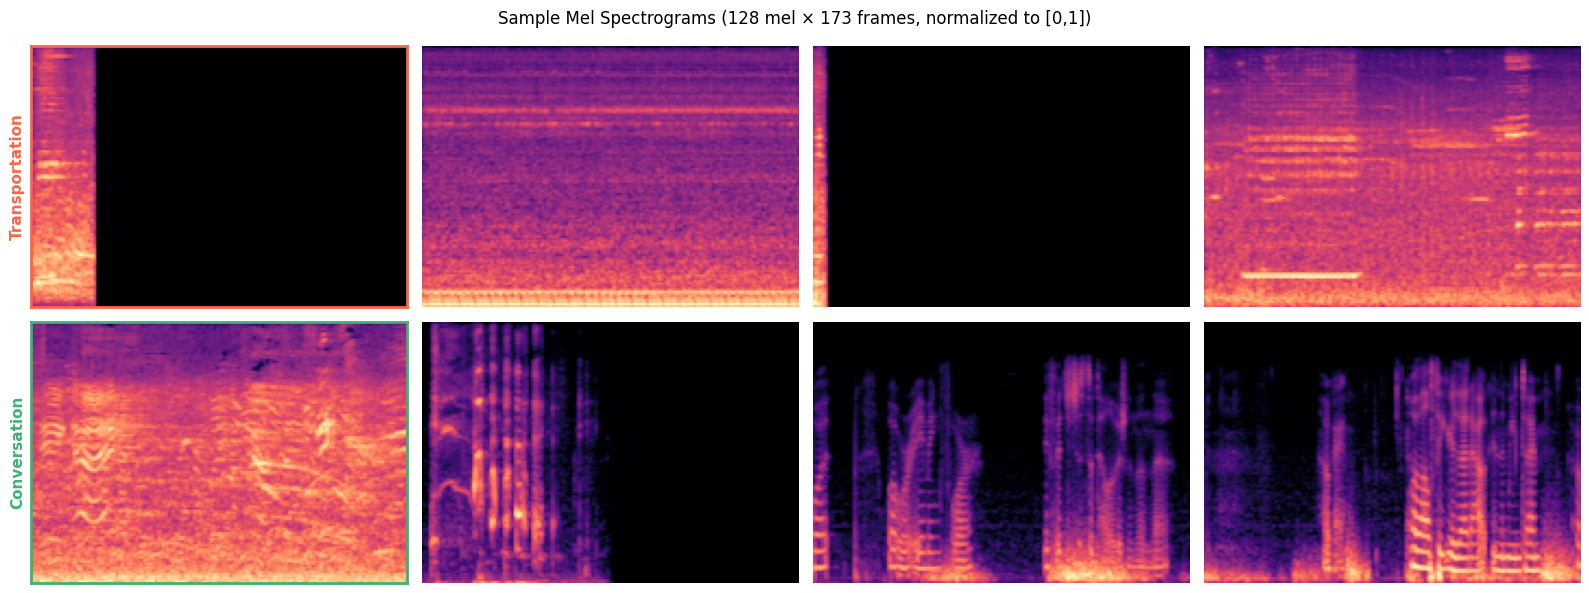

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for row_idx, (label, title) in enumerate([(0, 'Transportation'), (1, 'Conversation')]):
    idxs = np.where(y_all == label)[0]
    chosen = idxs[np.linspace(0, len(idxs)-1, 4, dtype=int)]
    color = 'tomato' if label == 0 else 'mediumseagreen'
    for col_idx, idx in enumerate(chosen):
        ax = axes[row_idx, col_idx]
        ax.imshow(X_all[idx], aspect='auto', origin='lower', cmap='magma')
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(title, color=color, fontsize=11, fontweight='bold')
            ax.axis('on')
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(2)

plt.suptitle('Sample Mel Spectrograms (128 mel × 173 frames, normalized to [0,1])', fontsize=12)
plt.tight_layout()
plt.show()